In [62]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import glob

In [63]:
for f in glob.glob("results/*.pdf"):
    os.remove(f)

# Purpose

Show that a simulated GO terms performance is a function of how much variance for a cell type there is when simulating bulk

### Load results

In [64]:
def load_results(path):
	"""Load the performance of simulated GO terms
	"""
	df = pd.read_csv(path, index_col=0)
	df['exp_type'] = df.loc[:,'organism_part'].str.split("_").str[0]
	df =  df[df.loc[:,'exp_type']=='exp']
	df['Q'] = df.loc[:,'index'].str.split("_").str[-1]
	return df

def aggr(df):
	agg = pd.DataFrame(df.groupby(['index'])['auc'].agg(['mean','std'])).reset_index()
	agg['Q'] = agg.loc[:,'index'].str.split("_").str[-1]
	return agg

def load_agg(path):
	df = load_results(path)
	df_agg = aggr(df)
	return df_agg

agg_with_exi = load_agg(path = "/space/grp/aadrian/Pseudobulk_Function_Pipeline_HighRes/bin/EGADSimulatedGOTerms/data/simgo_allcells/master_melted_df.csv.gz")
agg_no_exi = load_agg(path = "/space/grp/aadrian/Pseudobulk_Function_Pipeline_HighRes/bin/EGADSimulatedGOTerms/data/simgo_noexi/master_melted_df.csv.gz" )


### Merge

In [65]:
def merge_res(agg_with_exi, agg_no_exi):
	merged = pd.merge(agg_with_exi, agg_no_exi, on = 'index', suffixes=["_with_exi","_no_exi"])
	melted = merged.melt(id_vars = 'index', value_vars=['mean_with_exi',"mean_no_exi"])
	melted["Group"] = melted.loc[:,'index'].str.split("_").str[-1]
	return melted

melted_df = merge_res(agg_with_exi, agg_no_exi)
melted_df['variable'] = pd.Categorical(melted_df['variable'], categories=['mean_with_exi','mean_no_exi'])
melted_df = melted_df.query("Group != 'Q1'")

### Plot

/home/aadrian/miniforge3/envs/main_env/lib/python3.9/site-packages/plotnine/ggplot.py:718: PlotnineWarning: Saving 2.2 x 1.5 in image.
/home/aadrian/miniforge3/envs/main_env/lib/python3.9/site-packages/plotnine/ggplot.py:719: PlotnineWarning: Filename: results/exi_learnability.png
/home/aadrian/miniforge3/envs/main_env/lib/python3.9/site-packages/plotnine/ggplot.py:718: PlotnineWarning: Saving 2.2 x 1.5 in image.
/home/aadrian/miniforge3/envs/main_env/lib/python3.9/site-packages/plotnine/ggplot.py:719: PlotnineWarning: Filename: results/exi_learnability.pdf


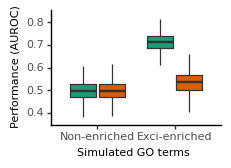

<ggplot: (8777091065323)>

In [85]:
from plotnine import *
import matplotlib.pyplot as plt

def boxplot(melted):

    p = (
        ggplot(
            melted,
            aes(x='Group', y='value', fill='variable')
        )
        + geom_boxplot(
            outlier_alpha=0  # hide outliers
        )
        + scale_x_discrete(
            labels=['Non-enriched', 'Exci-enriched']
        )
        + labs(
            x='Simulated GO terms',
            y='Performance (AUROC)'
        )
        + theme_classic()
        + theme(
            figure_size=(2.2, 1.5),
            axis_text_x=element_text(
                rotation=0,
                size=8
            ),
            

            axis_text_y=element_text(
                size=8
            ),

            axis_title_y=element_text(
                size=8
            ),

            axis_title_x=element_text(
                size=8
            ),

            legend_position='none'
        )
    )+ scale_fill_brewer(
        type='qual',
        palette='Dark2'
    )

    p.save("results/exi_learnability.png", dpi=300)
    p.save("results/exi_learnability.pdf")

    return p

boxplot(melted_df)

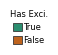

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns

def save_legend(melted, figsize=(0.75,0.75), fontsize=8):

    # Use Dark2 palette
    sns.set_palette("Dark2")
    sns.set_context("paper")

    # Temporary plot to extract legend info
    fig, ax = plt.subplots()

    melted['variable'] = melted['variable'].replace({
        'mean_no_exi': False,
        'mean_with_exi': True
    })

    sns.boxplot(
        data=melted,
        x='Group',
        y='value',
        hue='variable',
        ax=ax,
        showfliers=False
    )

    handles, labels = ax.get_legend_handles_labels()

    plt.close(fig)

    # Create legend-only figure
    fig_leg = plt.figure(figsize=figsize)
    ax_leg = fig_leg.add_subplot(111)
    ax_leg.axis("off")

    legend = ax_leg.legend(
        handles,
        labels,
        loc="center",
        frameon=False,
        fontsize=fontsize,
        title="Has Exci.",
        markerscale=0.4,
        handlelength=1,
        handleheight=1,
        handletextpad=0.2,
        borderpad=0
    )

    legend.get_title().set_fontsize(fontsize)

    plt.savefig(
        "results/exi_legend.pdf",
        bbox_inches=legend.get_window_extent().transformed(
            fig_leg.dpi_scale_trans.inverted()
        ),
        transparent=True
    )

    plt.savefig(
        "results/exi_legend.png",
        dpi=300,
        bbox_inches="tight",
        transparent=True
    )

    plt.show()
    plt.close()

save_legend(melted_df, figsize=(0.2,0.2), fontsize=6)

# Mixed effect Model

In [68]:
import statsmodels.formula.api as smf


def coerce_df_for_model():
	# Load dfs
	with_exi = load_results(path = "/space/grp/aadrian/Pseudobulk_Function_Pipeline_HighRes/bin/EGADSimulatedGOTerms/data/simgo_allcells/master_melted_df.csv.gz")
	no_exi = load_results(path = "/space/grp/aadrian/Pseudobulk_Function_Pipeline_HighRes/bin/EGADSimulatedGOTerms/data/simgo_noexi/master_melted_df.csv.gz" )

	# strip
	with_exi = with_exi.loc[:,['index','auc','bootstrap']]
	no_exi = no_exi.loc[:,['index','auc', 'bootstrap']]
	# merge dfs
	merged = pd.merge(with_exi, no_exi, on = ['index', 'bootstrap'], suffixes=["_with_exi","_no_exi"])

	# melt
	melted = merged.melt(id_vars=['index'], value_vars=['auc_with_exi','auc_no_exi'])
	melted["Group"] = pd.Categorical(melted.loc[:,'index'].str.split("_").str[-1], ordered = True, categories = ['Q2',"Q3"])
	melted = melted[melted['Group'].isin(['Q2','Q3'])]
	melted.columns = ['GO', 'expr_source', 'auc','Group']

	# model
	results = model_perf(melted)

	return results

def model_perf(melted):
	"""Mixed effects model where we model the effect of performance as a consequence of the function's differential expressed gene content. 
	
	But also model variance within different permutations of the method for each function

	Args:
		melted_df (_type_): _description_
	"""
	model = smf.mixedlm("auc ~ Group * expr_source", melted, groups=melted["GO"])
	results = model.fit()
	return results


def __main__():
	results = coerce_df_for_model()
	results.summary().tables[1].to_csv("results/mixedlm_coefficients.csv")
	return results


results = __main__()


/home/aadrian/miniforge3/envs/main_env/lib/python3.9/site-packages/statsmodels/regression/mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.


In [69]:
results.summary()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                       Mixed Linear Model Regression Results
===================================================================================
Model:                      MixedLM         Dependent Variable:         auc        
No. Observations:           199800          Method:                     REML       
No. Groups:                 1998            Scale:                      0.0011     
Min. group size:            100             Log-Likelihood:             395362.4424
Max. group size:            100             Converged:                  Yes        
Mean group size:            100.0                                                  
-----------------------------------------------------------------------------------
                                        Coef.  Std.Err.    z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------------------
Intercept                                0.499    0.001 401.367 0.000  0.496  0.501
Group[T.Q3]                              0.036    0.002  20.443 0.000  0.032  0.039
expr_source[T.auc_with_exi]             -0.001    0.000  -2.888 0.004 -0.001 -0.000
Group[T.Q3]:expr_source[T.auc_with_exi]  0.179    0.000 613.709 0.000  0.179  0.180
Group Var                                0.002    0.001                            
===================================================================================

"""

In [70]:
import numpy as np

def q_exi_contrast(results, group="Q3", expr="auc_with_exi"):
    """
    Compute contrast for a given Group and expr_source in a MixedLMResults object.
    Returns coef, SE, z, and p-value.
    """
    coef_names = [c for c in results.fe_params.index]
    n_coef = len(coef_names)

    # 2D contrast vector (1 row)
    L = np.zeros((1, n_coef))

    # baseline expr effect
    expr_coef_name = f"expr_source[T.{expr}]"
    L[0, coef_names.index(expr_coef_name)] = 1

    # interaction effect if not baseline group
    if group != "Q2":  # baseline group
        interaction_name = f"Group[T.{group}]:expr_source[T.{expr}]"
        L[0, coef_names.index(interaction_name)] = 1

    # Run t-test
    test = results.t_test(L)    
    return pd.DataFrame({
        "coef": test.effect[0],      # estimated difference
        "se": test.sd[0],            # standard error
        "z": test.tvalue[0],         # z-value
        "p": test.pvalue                  # p-value
    })
contrast_q3_withwithoutexi = q_exi_contrast(results, group="Q3", expr="auc_with_exi")
print(contrast_q3_withwithoutexi)

       coef        se           z    p
0  0.178573  0.000206  865.027834  0.0


In [71]:
def cross_group_contrast(results, group1, expr1, group2, expr2):
    """
    Contrast between (group1 + expr1) vs (group2 + expr2)
    """
    coef_names = results.fe_params.index.tolist()
    L = np.zeros((1, len(coef_names)))

    # Add coefficients for group1 + expr1
    if group1 != "Q2":
        L[0, coef_names.index(f"Group[T.{group1}]")] = 1
    if expr1 != "non-excitory":
        L[0, coef_names.index(f"expr_source[T.{expr1}]")] = 1
        if group1 != "Q2":
            L[0, coef_names.index(f"Group[T.{group1}]:expr_source[T.{expr1}]")] = 1

    # Subtract coefficients for group2 + expr2
    if group2 != "Q2":
        L[0, coef_names.index(f"Group[T.{group2}]")] -= 1
    if expr2 != "non-excitory":
        L[0, coef_names.index(f"expr_source[T.{expr2}]")] -= 1
        if group2 != "Q2":
            L[0, coef_names.index(f"Group[T.{group2}]:expr_source[T.{expr2}]")] -= 1

    # Run t-test
    test = results.t_test(L)
    return pd.DataFrame({
        "coef": test.effect[0],
        "se": test.sd[0],
        "z": test.tvalue[0],
        "p": test.pvalue
    })

contrast_q3_vs_q2_withexi = cross_group_contrast(
    results,
    group1="Q3", expr1="auc_with_exi",
    group2="Q2", expr2="non-excitory"
)
print(contrast_q3_vs_q2_withexi)

       coef        se           z    p
0  0.214505  0.001758  122.039737  0.0


In [72]:
def predicted_auc(results, group, expr):
    """
    Compute the model-predicted mean AUC for a given (group, expr_source) condition.
    Baseline is Q2 x auc_no_exi.
    """
    coef_names = results.fe_params.index.tolist()
    L = np.zeros((1, len(coef_names)))

    # Intercept always included
    L[0, coef_names.index("Intercept")] = 1

    # Group offset (if not baseline Q2)
    if group != "Q2":
        L[0, coef_names.index(f"Group[T.{group}]")] = 1

    # expr_source offset (if not baseline auc_no_exi)
    if expr != "auc_no_exi":
        L[0, coef_names.index(f"expr_source[T.{expr}]")] = 1
        if group != "Q2":
            L[0, coef_names.index(f"Group[T.{group}]:expr_source[T.{expr}]")] = 1

    test = results.t_test(L)
    return pd.DataFrame({
        "group": group,
        "expr_source": expr,
        "predicted_auc": test.effect[0],
        "ci_lower": test.conf_int()[0][0],
        "ci_upper": test.conf_int()[0][1],
    }, index=[0])


def print_predicted_aucs(results):
    rows = []
    for group in ["Q2", "Q3"]:
        for expr in ["auc_no_exi", "auc_with_exi"]:
            rows.append(predicted_auc(results, group, expr))
    table = pd.concat(rows, ignore_index=True)
    print(table.to_string(index=False))
    return table

print_predicted_aucs(results)


group  expr_source  predicted_auc  ci_lower  ci_upper
   Q2   auc_no_exi       0.498843  0.496407  0.501279
   Q2 auc_with_exi       0.498247  0.495811  0.500683
   Q3   auc_no_exi       0.534775  0.532339  0.537211
   Q3 auc_with_exi       0.713348  0.710912  0.715784


,group,expr_source,predicted_auc,ci_lower,ci_upper
0,Q2,auc_no_exi,0.498843,0.496407,0.501279
1,Q2,auc_with_exi,0.498247,0.495811,0.500683
2,Q3,auc_no_exi,0.534775,0.532339,0.537211
3,Q3,auc_with_exi,0.713348,0.710912,0.715784
